## Autoregressive model

The autoregressive model is a statistical technique used in time-series analysis that assumes the current value of a time series is a function of its past values. The autoregressive process of order $p$ is denoted AR($p$), and expressed as a linear combination of past values with a random error term, defined by

$$y_t = \phi_1y_{t-1}+\phi_2y_{t-2}...+\phi_py_{t-p}+w_t\text{,}$$

which can be rewritten as

$$y_t = \sum_{j=1}^p\phi_jy_{t-j}+ w_t\text{,}$$

where $\phi_1, \phi_2,..., \phi_p$ are fixed constants and $w_t$ is a random variable with mean 0 and variance $\sigma^2$. 

If the mean, $\mu$, of $y_t$ is not zero, we replace $y_t$ by $y_t-\mu$:

$$y_t-\mu = \sum_{j=1}^p\phi_j(y_{t-j}-\mu)+ w_t$$

Autoregressive processes have a natural interpretation as the next observed value is just a small perturbation of the most recent observed value. In other words, the current value of the series  is linearly dependent upon its previous values, plus a random error term. This type of model is called an *autoregressive* (AR) model because the variable $y_t$ is regressed on its own past values.

Since past observations influence the current value, autoregressive models are well suited for analyzing processes that evolve over time, such as those found in economics, environmental science, and other natural systems. In contrast to multiple regression models, which predict a variable using a linear combination of external predictors, autoregressive models use the past values of the series itself as predictors.

The common notation is AR(1) for a autoregressive process of order 1, where the current value is based only on the immediately preceding value, AR(2) denotes an autoregressive process of order 2, where the current value is based on the previous two values. An AR(0) process has no dependence between the terms, and is used e.g. for white noise.

## AR(1) Example

The special case of $p = 1$, the first-order process, is also known as [Markov process](https://en.wikipedia.org/wiki/Markov_chain).

In the following example, we generate two AR(1) series of the form

$y_t = \phi_1 y_{t-1}+w_t\text{,}$

where one $\phi_1 = 0.6$ and the other $\phi_1 = -0.6$. Notice that  the sign of coefficients in the code is opposite!

In [1]:
%load_ext lab_black

In [1]:
# Importing necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

In [2]:
# Seed random number generator
random.seed(250)

from statsmodels.tsa.arima_process import ArmaProcess

# Plot 1: AR parameter =+0.6
ar1 = np.array([1, -0.6])  # opposite sign!
ma1 = np.array([1])  # we have to include the zero-lag coefficient of 1
AR_object1 = ArmaProcess(ar1, ma1)
simulated_ar1_1 = AR_object1.generate_sample(nsample=100)

# Plot 2: AR parameter = -0.6
ar2 = np.array([1, 0.6])  # opposite sign!
ma2 = np.array([1])  # we have to include the zero-lag coefficient of 1
AR_object2 = ArmaProcess(ar2, ma2)
simulated_ar1_2 = AR_object2.generate_sample(nsample=100)


We plot the two series:


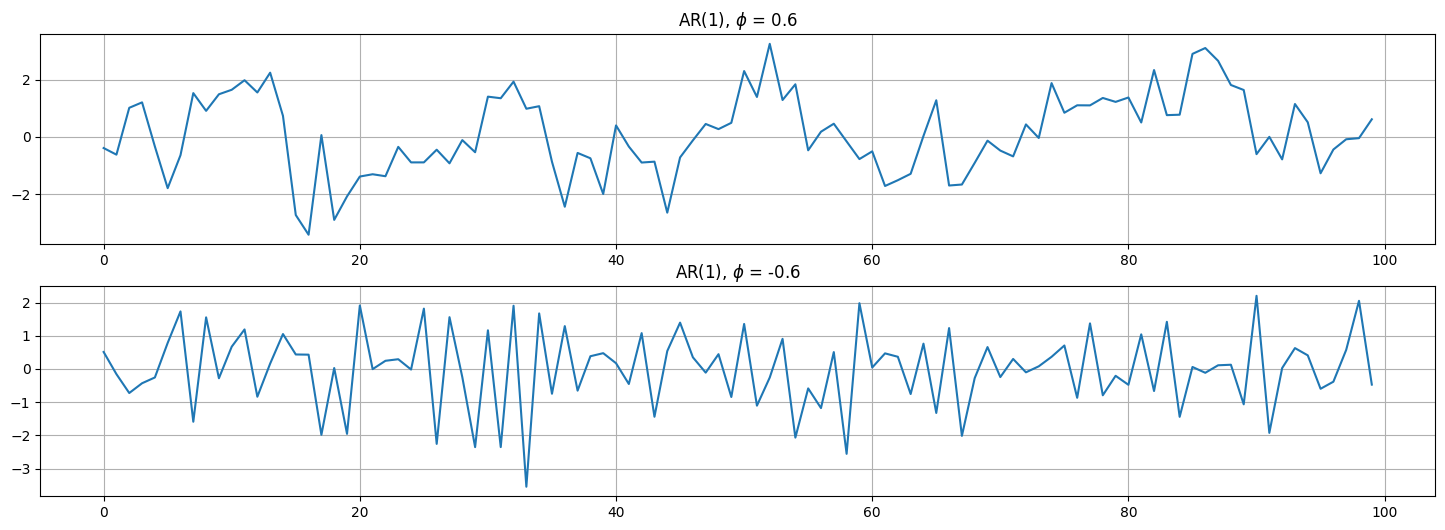

In [ ]:
# Plot the two AR(1) series
fig, ax = plt.subplots(2, 1, figsize=(18, 6))
ax[0].plot(simulated_ar1_1)
ax[0].set_title("AR(1), $\\phi$ = 0.6")
ax[0].grid()

ax[1].plot(simulated_ar1_2)
ax[1].set_title("AR(1), $\\phi$ = -0.6")
ax[1].grid()

plt.show()


It is known that for an AR(1) model the current value $y_t$ of the time series is a function of the last preceding value of the series. We can review the correlational structure by plotting the correlogram. 



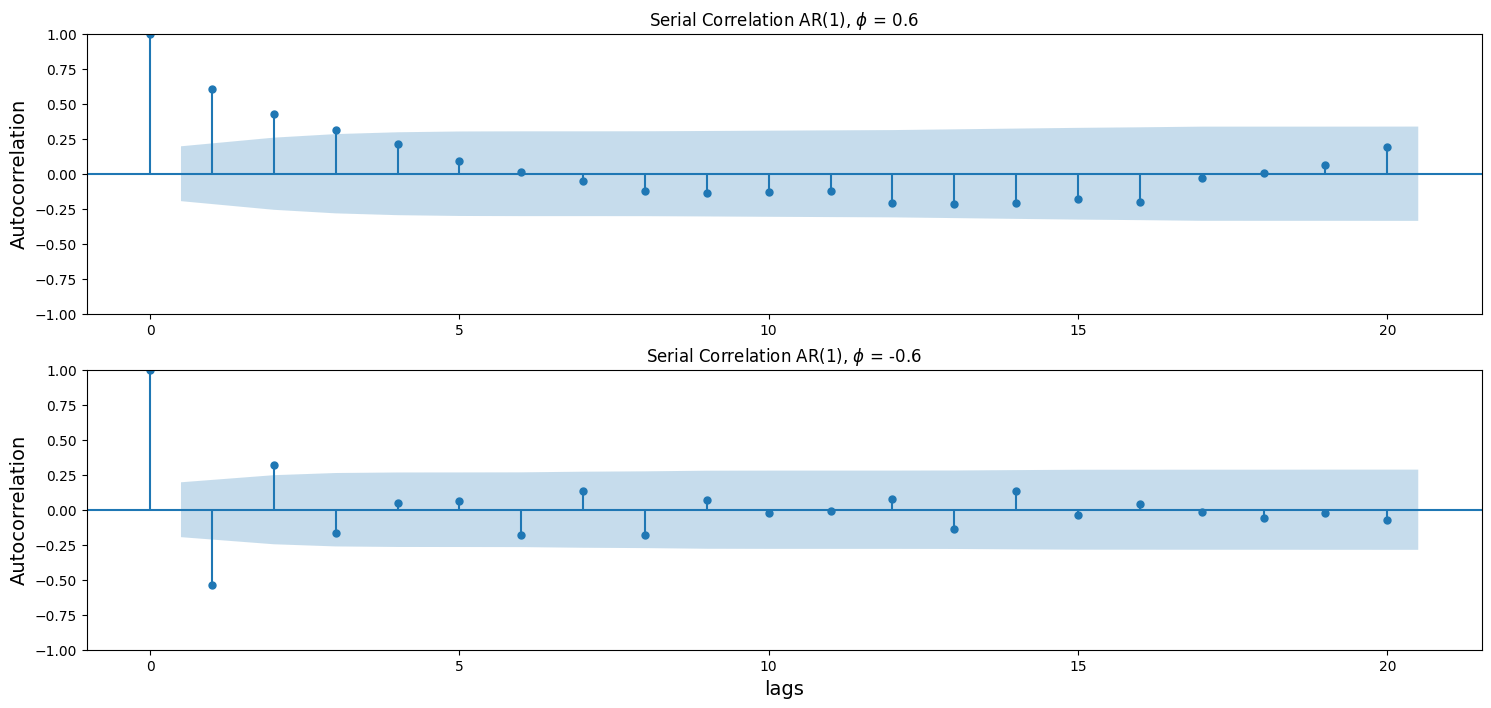

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot the autocorrelation function of the two AR(1) series
fig, ax = plt.subplots(2, 1, figsize=(18, 8))

plot_acf(simulated_ar1_1, ax=ax[0])
ax[0].set_title("Serial Correlation AR(1), $\\phi$ = 0.6")
ax[0].set_ylabel("Autocorrelation", fontsize=14)

plot_acf(simulated_ar1_2, ax=ax[1])
ax[1].set_title("Serial Correlation AR(1), $\\phi$ = -0.6")
ax[1].set_xlabel("lags", fontsize=14)
ax[1].set_ylabel("Autocorrelation", fontsize=14)

plt.show()

The autocorrelation function for the AR series at lag 1 equal the parameter $\phi$, and decays exponentially, where the rate of decay is know to depend on $\phi$. A large $|\phi|$ produces strong persistence, while a small $|\phi|$ leads to weak autocorrelation. Additionally, the autocorrelation function displays a possible sinusoidal variation superimposed, and for $\phi <0$ the autocorrelation function tends to alternate sign. 

## AR(2) Example

For an AR(2) model, which can be written as 

$y_t = \phi_1 y_{t-1}+\phi_2 y_{t-2}+w_t\text{,}$

the current value $y_t$ of the time series is a function of the last two preceding values of the series.

Let us generate four different AR(2) series to review their autocorrelational structures. 

* AR(2) model I: $\phi_1 = 0.5$  and  $\phi_2 = 0.3$  
* AR(2) model II: $\phi_1 = -0.5$  and  $\phi_2 = 0.3$  
* AR(2) model III: $\phi_1 = 1$  and  $\phi_2 = -0.5$  
* AR(2) model IV: $\phi_1 = -0.5$  and  $\phi_2 = -0.3$.  

We make use of the `arima.sim()` function  to generate these four AR(2) models and plot the correlogram by using the `autoplot()` function in combination with the `acf()` function.


In [10]:
# Generating four AR(2) series with different parameters
# AR parameter = 0.5, 0.3
ar2_I = np.array([2, -0.5, -0.3])
ma2_I = np.array([1])
AR_object2_I = ArmaProcess(ar2_I, ma2_I)
simulated_ar2_I_1 = AR_object2_I.generate_sample(nsample=100)

# AR parameter = -0.5, 0.3
ar2_II = np.array([2, +0.5, -0.3])
ma2_II = np.array([1])
AR_object2_II = ArmaProcess(ar2_II, ma2_II)
simulated_ar2_II_1 = AR_object2_II.generate_sample(nsample=100)

# AR parameter = 1, -0.5
ar2_III = np.array([2, -1, +0.5])
ma2_III = np.array([1])
AR_object2_III = ArmaProcess(ar2_III, ma2_III)
simulated_ar2_III_1 = AR_object2_III.generate_sample(nsample=100)

# AR parameter = +0.6
ar2_IV = np.array([2, +0.5, -0.3])
ma2_IV = np.array([2])
AR_object2_IV = ArmaProcess(ar2_IV, ma2_IV)
simulated_ar2_IV_1 = AR_object2_IV.generate_sample(nsample=100)

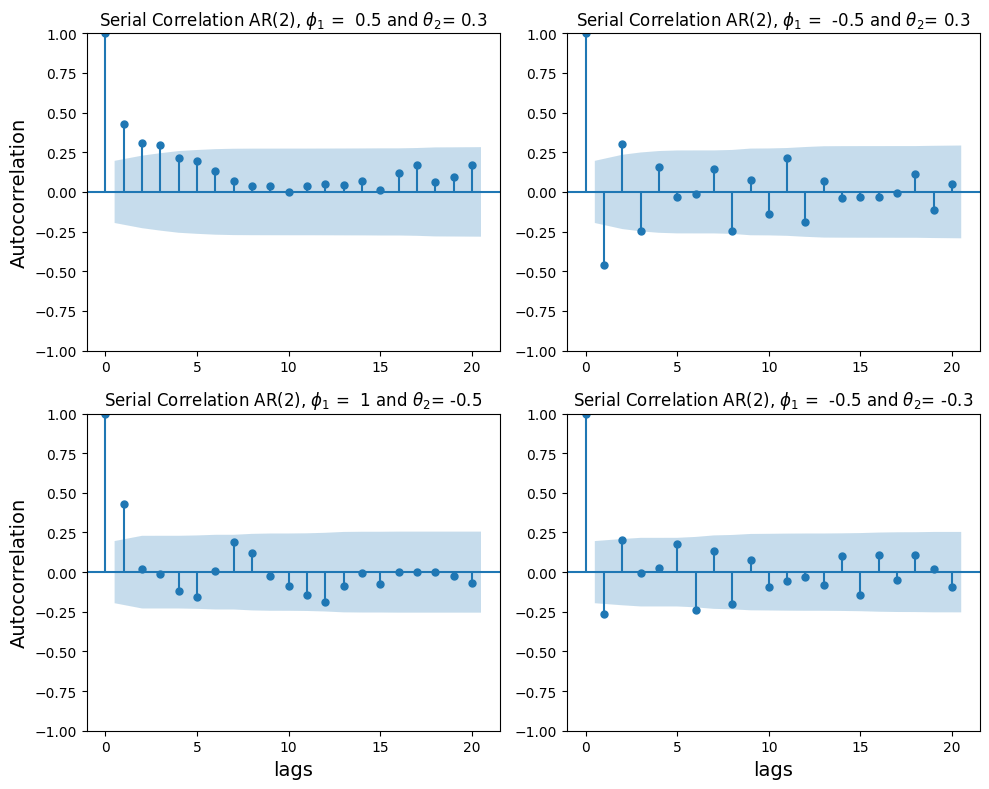

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot the autocorrelation function of the four AR(2) series
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

plot_acf(simulated_ar2_I_1, ax=ax[0, 0])
ax[0, 0].set_title("Serial Correlation AR(2), $\\phi_1$ =  0.5 and $\\theta_2$= 0.3")
ax[0, 0].set_ylabel("Autocorrelation", fontsize=14)

plot_acf(simulated_ar2_II_1, ax=ax[0, 1])
ax[0, 1].set_title("Serial Correlation AR(2), $\\phi_1$ =  -0.5 and $\\theta_2$= 0.3 ")

plot_acf(simulated_ar2_III_1, ax=ax[1, 0])
ax[1, 0].set_title("Serial Correlation AR(2), $\\phi_1$ =  1 and $\\theta_2$= -0.5")
ax[1, 0].set_xlabel("lags", fontsize=14)
ax[1, 0].set_ylabel("Autocorrelation", fontsize=14)

plot_acf(simulated_ar2_IV_1, ax=ax[1, 1])
ax[1, 1].set_title("Serial Correlation AR(2), $\\phi_1$ =  -0.5 and $\\theta_2$= -0.3")
ax[1, 1].set_xlabel("lags", fontsize=14)

plt.tight_layout()
plt.show()



All the autocovariance functions exhibit exponential decay depending on both $\phi_1$ and $\theta_2$, with possible sinusoidal variation superimposed.



### Forecasting 

Further, the AR model as well as the MA can be used for forecasting, as we will show next using the full ARIMA model

#### Summary:

* An autoregressive model expresses the current value of a time series as a linear combination of its previous values.
* More specifically, AR(p) models depend on the previous p observations of the series.
* The autocorrelation function typically displays exponential decay with possible sinusoidal variation superimposed.

In [1]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))